In [126]:
import numpy as np 
import pandas as pd 
import seaborn as sns

In [127]:
df = pd.read_csv('/Users/mac/Desktop/projects/zoomcamp_ml/2025_ml/car_fuel_efficiency.csv')
df.head()

,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,model_year,origin,fuel_type,drivetrain,num_doors,fuel_efficiency_mpg
0,170,3.0,159.0,3413.433759,17.7,2003,Europe,Gasoline,All-wheel drive,0.0,13.231729
1,130,5.0,97.0,3149.664934,17.8,2007,USA,Gasoline,Front-wheel drive,0.0,13.688217
2,170,NaN,78.0,3079.038997,15.1,2018,Europe,Gasoline,Front-wheel drive,0.0,14.246341
3,220,4.0,NaN,2542.392402,20.2,2009,USA,Diesel,All-wheel drive,2.0,16.912736
4,210,1.0,140.0,3460.870990,14.4,2009,Europe,Gasoline,All-wheel drive,2.0,12.488369


In [128]:
df = df[['engine_displacement', 'horsepower', 'vehicle_weight', 'model_year', 'fuel_efficiency_mpg']]
df

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
0,170,159.0,3413.433759,2003,13.231729
1,130,97.0,3149.664934,2007,13.688217
2,170,78.0,3079.038997,2018,14.246341
3,220,NaN,2542.392402,2009,16.912736
4,210,140.0,3460.870990,2009,12.488369
...,...,...,...,...,...
9699,140,164.0,2981.107371,2013,15.101802
9700,180,154.0,2439.525729,2004,17.962326
9701,220,138.0,2583.471318,2008,17.186587
9702,230,177.0,2905.527390,2011,15.331551


<Axes: xlabel='fuel_efficiency_mpg', ylabel='Count'>

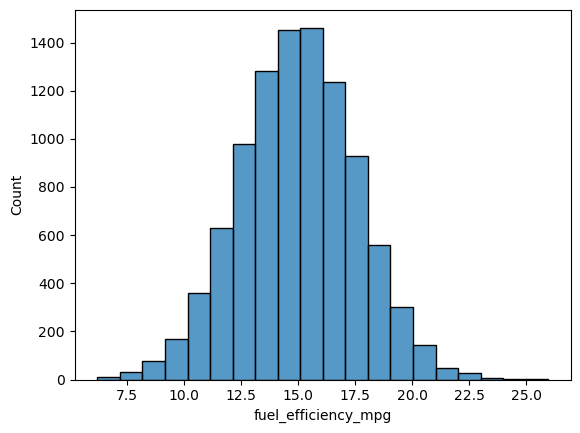

In [129]:
sns.histplot(df['fuel_efficiency_mpg'], bins=20)

In [130]:
df.isnull().sum()

engine_displacement      0
horsepower             708
vehicle_weight           0
model_year               0
fuel_efficiency_mpg      0
dtype: int64

In [131]:
df['horsepower'].describe()

count    8996.000000
mean      149.657292
std        29.879555
min        37.000000
25%       130.000000
50%       149.000000
75%       170.000000
max       271.000000
Name: horsepower, dtype: float64

In [132]:
np.random.seed(42)
n = len(df)

n_train = int(0.6 * n)
n_val = int(0.2 * n)
n_test = n - n_train - n_val


idx = np.arange(n)
np.random.shuffle(idx)

df_train = df.iloc[idx[:n_train]]
df_val = df.iloc[idx[n_train:n_train+n_val]]
df_test = df.iloc[idx[n_train+n_val:]]

In [133]:
df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

print(len(df_train), len(df_val), len(df_test))

5822 1940 1942


In [134]:
y_train = df_train.fuel_efficiency_mpg.values.reshape(-1, 1)
y_val = df_val.fuel_efficiency_mpg.values.reshape(-1, 1)
y_test = df_test.fuel_efficiency_mpg.values.reshape(-1, 1)


del df_train['fuel_efficiency_mpg']
del df_val['fuel_efficiency_mpg']
del df_test['fuel_efficiency_mpg']



In [135]:
df_train_zeros = df_train.copy()
df_val_zeros = df_val.copy()

df_train_mean = df_train.copy()
df_val_mean = df_val.copy()

mean_value = df_train['horsepower'].mean()

df_train_zeros['horsepower'] = df_train_zeros['horsepower'].fillna(0)
df_val_zeros['horsepower'] = df_val_zeros['horsepower'].fillna(0)

df_train_mean['horsepower'] = df_train['horsepower'].fillna(mean_value)
df_val_mean['horsepower'] = df_val['horsepower'].fillna(mean_value)

In [136]:
X_train_zeros = df_train_zeros.values
X_val_zeros = df_val_zeros.values

X_train_mean = df_train_mean.values
X_val_mean = df_val_mean.values

print(X_train_zeros.shape, y_train.shape)

(5822, 4) (5822, 1)


In [137]:
X_train_mean.shape

(5822, 4)

In [138]:
def train_linear_regression(X, y):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX_inv = np.linalg.inv(XTX)
    w = XTX_inv.dot(X.T).dot(y)
    
    return w[0], w[1:]

In [139]:
w_0, w = train_linear_regression(X_train_zeros, y_train)
y_pred = w_0 + X_train_zeros.dot(w)

<Axes: ylabel='Count'>

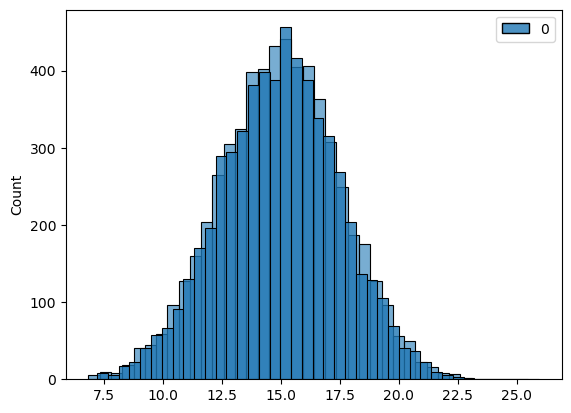

In [140]:
sns.histplot(y_train, label='target', color='blue', alpha=0.6, bins=40)
sns.histplot(y_pred, label='prediction', color='red', alpha=0.8, bins=40)

In [141]:
def rmse(y, y_pred):
    error = y_pred - y
    mse = (error ** 2).mean()
    result = np.sqrt(mse)
    return result

In [142]:
result = rmse(y_train, y_pred)
result

np.float64(0.5203457641474558)

In [143]:
w_0, w = train_linear_regression(X_train_mean, y_train)
y_pred_mean = w_0 + X_train_mean.dot(w)

In [144]:
y_pred_mean_val = w_0 + X_val_mean.dot(w)
rmse(y_val, y_pred_mean_val)

np.float64(0.4635366017443467)

<Axes: ylabel='Count'>

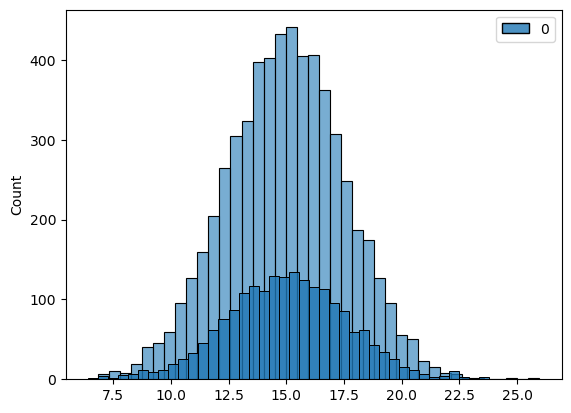

In [145]:
sns.histplot(y_train, label='target', color='red', alpha=0.6, bins=40)
sns.histplot(y_pred_mean_val, label='prediction', color='blue', alpha=0.8, bins=40)

In [146]:
def train_linear_regression_reg(X, y, r=0.0):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    reg = r * np.eye(XTX.shape[0])
    XTX = XTX + reg

    XTX_inv = np.linalg.inv(XTX)
    w = XTX_inv.dot(X.T).dot(y)
    
    return w[0], w[1:]

In [147]:
for r in [0, 0.01, 0.1, 1, 5, 10, 100]:
    w_0, w = train_linear_regression_reg(X_train_zeros, y_train, r=r)
    X_val = X_val_zeros
    y_pred = w_0 + X_val.dot(w)
    score = round(rmse(y_val, y_pred), 2)
    
    print(r, w_0, score)

0 [28.81074933] 0.52
0.01 [24.9105054] 0.52
0.1 [11.22918818] 0.52
1 [1.72965198] 0.52
5 [0.36338862] 0.52
10 [0.18285103] 0.52
100 [0.01839669] 0.52


In [148]:
seeds = list(range(10))
scores = []

for seed in range(10):
    np.random.seed(seed)
    n = len(df)
    idx = np.arange(n)
    np.random.shuffle(idx)
    train_size = int(0.6 * n)
    val_size = int(0.2 * n)
    test_size = n - train_size - val_size
    
    df_train = df.iloc[idx[:train_size]].reset_index(drop=True)
    df_val = df.iloc[idx[train_size:train_size+val_size]].reset_index(drop=True)
    df_test = df.iloc[idx[train_size+val_size:]].reset_index(drop=True)

    y_train = df_train.fuel_efficiency_mpg.values.reshape(-1, 1)
    y_val = df_val.fuel_efficiency_mpg.values.reshape(-1, 1)
    y_test = df_test.fuel_efficiency_mpg.values.reshape(-1, 1)


    del df_train['fuel_efficiency_mpg']
    del df_test['fuel_efficiency_mpg']
    del df_val['fuel_efficiency_mpg']

    df_train['horsepower'].fillna(0, inplace=True)
    df_val['horsepower'].fillna(0, inplace=True)
    


    X_train = df_train.values
    X_val = df_val.values

    w_0, w = train_linear_regression(X_train, y_train)
    y_pred = w_0 + X_val.dot(w)
    score = rmse(y_val, y_pred)
    scores.append(score)
    print(f'Seed: {seed}, RMSE: {score}')
    print('------------------------')

std = round(np.std(scores), 3)
print(f'Std: {std}')

Seed: 0, RMSE: 0.5210993169575029
------------------------
Seed: 1, RMSE: 0.5218422383637982
------------------------
Seed: 2, RMSE: 0.5230384519921711
------------------------
Seed: 3, RMSE: 0.5161215334679159
------------------------
Seed: 4, RMSE: 0.5111869530228665
------------------------
Seed: 5, RMSE: 0.5286833855487454
------------------------
Seed: 6, RMSE: 0.5322418918536721
------------------------
Seed: 7, RMSE: 0.5095258233917545
------------------------
Seed: 8, RMSE: 0.5149083792385314
------------------------
Seed: 9, RMSE: 0.5131330922635593
------------------------
Std: 0.007


/var/folders/5m/3fqmnj9x6yg0_7b6pc8y_12m0000gn/T/ipykernel_3726/2242892292.py:26: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_train['horsepower'].fillna(0, inplace=True)
/var/folders/5m/3fqmnj9x6yg0_7b6pc8y_12m0000gn/T/ipykernel_3726/2242892292.py:27: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always

In [149]:
from sklearn.model_selection import train_test_split

def evaluate_seed_influence(df, X, y):
    seeds = list(range(10))  # [0, 1, 2, ..., 9]
    rmse_scores = []

    for seed in seeds:
        # Train/Validation/Test split (60%/20%/20%)
        df_train, df_temp = train_test_split(df, test_size=0.4, random_state=seed)
        df_val, df_test = train_test_split(df_temp, test_size=0.5, random_state=seed)

        # Fill missing values with 0
        df_train.fillna(0, inplace=True)
        df_val.fillna(0, inplace=True)


        # Prepare training data
        X_train = df_train[X].values
        y_train = df_train[y].values

        # Prepare validation data
        X_val = df_val[X].values
        y_val = df_val[y].values

        # Train a linear regression model (without regularization)
        w_0, w = train_linear_regression(X_train, y_train)
        y_pred = w_0 + X_train.dot(w)

        # Make predictions
        y_pred = w_0 + X_val.dot(w)

        # Compute RMSE
        result = rmse(y_val, y_pred)
        rmse_scores.append(result)

    # Compute the standard deviation of RMSE scores
    std_rmse = np.std(rmse_scores)
    
    return round(std_rmse,3)


result = evaluate_seed_influence(df, X=['engine_displacement','horsepower', 'vehicle_weight', 'model_year'], y='fuel_efficiency_mpg')
print("Standard deviation of RMSE:", result)

Standard deviation of RMSE: 0.006


In [150]:
np.random.seed(9)
n = len(df)

n_train = int(0.6 * n)
n_val = int(0.2 * n)
n_test = n - n_train - n_val



# print(n, n_val, n_test, n_train)
# print(n, n_train + n_val + n_test)


df_train = df.iloc[:n_train].reset_index(drop=True)
df_val = df.iloc[n_train:n_train+n_val].reset_index(drop=True)
df_test = df.iloc[n_train+n_val:].reset_index(drop=True)

df_combined = pd.concat([df_train, df_val])


y_train = df_combined.fuel_efficiency_mpg.values.reshape(-1, 1)
y_test = df_test.fuel_efficiency_mpg.values.reshape(-1, 1)


del df_train['fuel_efficiency_mpg']
del df_test['fuel_efficiency_mpg']
del df_combined['fuel_efficiency_mpg']

In [151]:
y_test

array([[ 9.08017025],
       [21.11410667],
       [14.27237387],
       ...,
       [17.18658678],
       [15.33155059],
       [14.8844674 ]])

In [152]:
df_combined.isnull().sum()

engine_displacement      0
horsepower             575
vehicle_weight           0
model_year               0
dtype: int64

In [157]:
df_combined.dtypes

engine_displacement      int64
horsepower             float64
vehicle_weight         float64
model_year               int64
dtype: object

In [153]:
df_combined.fillna(0, inplace=True)
df_combined.isnull().sum()

engine_displacement    0
horsepower             0
vehicle_weight         0
model_year             0
dtype: int64

In [162]:
df_test.fillna(0, inplace=True)
df_test.isnull().sum()

engine_displacement    0
horsepower             0
vehicle_weight         0
model_year             0
dtype: int64

In [163]:
X_train = df_combined.values

X_test = df_test.values
print(X_train.shape, y_train.shape, y_test.shape, X_test.shape)

(7762, 4) (7762, 1) (1942, 1) (1942, 4)


In [ ]:
w_0, w= train_linear_regression_reg(X_train, y_train, r=0.001)
y_pred = w_0 + X_test.dot(w)

score = rmse(y_test, y_pred)
print(score)

0.5104841007542957
